### **CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS**

Nesta célula, importamos as bibliotecas necessárias para a manipulação dos dados,
construção dos modelos de Machine Learning e avaliação dos resultados.

- **pandas**: manipulação e análise de dados
- **numpy**: operações matemáticas
- **matplotlib** e **seaborn**: visualização de dados
- **scikit-learn**: implementação dos modelos e métricas

In [ ]:
# =============================================================================
# CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuração visual
sns.set(style="whitegrid")

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento da Base de Dados

Nesta etapa do projeto, realiza-se o carregamento da base de dados que será utilizada para o desenvolvimento e avaliação dos modelos de Inteligência Artificial propostos: Regressão Logística e Árvores de Decisão.

A base de dados é importada utilizando a biblioteca **pandas**, amplamente empregada em projetos de Ciência de Dados e Aprendizado de Máquina, por oferecer estruturas e métodos eficientes para manipulação e análise de dados tabulares.

O procedimento de leitura considera:
- A codificação **Latin-1**, garantindo a correta interpretação de caracteres acentuados presentes no conjunto de dados;
- O separador de campos definido como vírgula (``,`), conforme o padrão do arquivo CSV;
- A ausência de cabeçalho no arquivo original, indicada pelo parâmetro `header=None`.

Além disso, foi implementado um tratamento de exceções para identificar possíveis erros no carregamento do arquivo, como a ausência da base de dados no diretório de execução. Caso o arquivo seja carregado corretamente, são exibidas as cinco primeiras linhas do conjunto de dados, permitindo uma verificação inicial de sua estrutura e conteúdo.

Essa etapa é fundamental, pois assegura que os dados estejam corretamente disponíveis para as fases subsequentes de pré-processamento, análise exploratória e treinamento dos modelos de Aprendizado de Máquina.

In [ ]:
# =============================================================================
# CÉLULA 2: CARREGAMENTO DA BASE DE DADOS
# =============================================================================

try:
    df = pd.read_csv(
        "baseMLJurandir.csv",
        encoding="latin1",
        sep=",",
        header=0,  # Alterado de 'None' para '0' para usar a primeira linha como cabeçalho
        engine="python"
    )
    print(f"Dataset carregado com sucesso! Dimensões: {df.shape}")

except FileNotFoundError:
    print("Erro: arquivo não encontrado.")
    df = None  # Define df como None se o arquivo não for encontrado

else:
    print("\nPrimeiras 5 linhas do dataset:")
    display(df.head())

Dataset carregado com sucesso! Dimensões: (1084215, 12)

Primeiras 5 linhas do dataset:


,saltos,nÃÂºcleo,modulaÃÂ§ÃÂ£o,comprimento,primeiro slot,ultimo slot,XT,OSNR,banda,consumo energia,peso,resultado
0,1,5,16.0,1050.0,1,3,-120.0,16.613496,2.000000e+11,0.0,0.0,1
1,3,5,4.0,2850.0,1,3,-120.0,12.349501,1.000000e+11,0.0,0.0,1
2,3,5,4.0,2850.0,1,10,-120.0,12.227845,4.000000e+11,0.0,0.0,1
3,3,5,4.0,2850.0,1,8,-120.0,12.253261,3.000000e+11,0.0,0.0,1
4,3,5,8.0,1550.0,1,9,-120.0,14.713263,5.000000e+11,0.0,0.0,1


## Célula 3 – Pré-processamento e Engenharia de Features

Nesta célula é realizada a etapa de **pré-processamento e engenharia de features**, cujo objetivo é transformar a base de dados original em um formato adequado para a aplicação dos modelos de Inteligência Artificial. Essa fase é essencial para garantir a qualidade dos dados, reduzir inconsistências e facilitar o aprendizado dos algoritmos de classificação.

### Correção de colunas com erro de encoding

Durante a importação do arquivo CSV, algumas colunas apresentaram problemas de codificação de caracteres, especialmente aquelas que continham acentuação, resultando em nomes incorretos como *nÃÂºcleo* e *modulaÃÂ§ÃÂ£o*. Para solucionar esse problema, foi definida uma função auxiliar responsável por mapear e corrigir automaticamente esses nomes, substituindo-os por suas versões corretas (*núcleo* e *modulação*). Essa etapa evita erros de referência às colunas nas fases seguintes do projeto.

### Criação da variável target (`aceito`)

A coluna original `resultado` foi utilizada para criar uma nova variável binária denominada `aceito`, que representa a variável alvo do problema de classificação. Quando o valor de `resultado` é igual a 1, o circuito é considerado aceito (`aceito = 1`); caso contrário, é considerado bloqueado (`aceito = 0`). Essa variável será utilizada como saída esperada pelos modelos de Regressão Logística e Árvore de Decisão.

### Remoção da coluna `resultado`

Após a criação da variável target `aceito`, a coluna `resultado` torna-se redundante e, portanto, é removida do conjunto de dados. Essa remoção contribui para a redução de dimensionalidade e evita duplicidade de informação.

### Criação da feature `slots_usados`

As colunas `primeiro_slot` e `ultimo_slot` foram combinadas para gerar uma nova feature denominada `slots_usados`, que representa a quantidade total de slots utilizados em cada circuito. Essa nova variável fornece uma informação mais direta e relevante para o processo de aprendizado dos modelos. Após sua criação, as colunas originais são removidas do DataFrame.

### Tratamento da variável categórica `modulação`

A coluna `modulação` representa uma variável categórica, a qual não pode ser utilizada diretamente por algoritmos de Machine Learning que exigem entradas numéricas. Para resolver esse problema, foi aplicado o método de **Label Encoding**, que converte cada categoria distinta de modulação em um valor numérico inteiro, permitindo sua utilização nos modelos de classificação.

### Verificação final do conjunto de dados

Por fim, é realizada a exibição das primeiras linhas do DataFrame resultante, permitindo a verificação das transformações aplicadas e confirmando que o conjunto de dados está devidamente estruturado e pronto para a etapa de treinamento dos modelos.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Função para corrigir nomes de colunas com erro de encoding
# -----------------------------
def corrigir_coluna(nome_coluna):
    # Atualizado para corresponder aos caracteres garbled reais no DataFrame
    correcoes = {
        "nÃÂºcleo": "núcleo",
        "modulaÃÂ§ÃÂ£o": "modulação",
        "primeiro slot": "primeiro_slot",
        "ultimo slot": "ultimo_slot",
        # Adicionando um mapeamento para um possível nome genérico de coluna alvo
        "Unnamed: 11": "resultado" # Assumindo que a 12ª coluna (índice 11) é o 'resultado' sem cabeçalho
    }
    return correcoes.get(nome_coluna, nome_coluna)

# Aplicar correção nos nomes das colunas
df.columns = [corrigir_coluna(col) for col in df.columns]

# -----------------------------
# Criação da variável target (aceito)
# -----------------------------
df["aceito"] = df["resultado"].fillna(0).apply(lambda x: 1 if int(x) == 1 else 0)

# Remover a coluna original 'resultado'
df = df.drop(columns=["resultado"])

# -----------------------------
# Criação da feature 'slots_usados'
# -----------------------------
df["slots_usados"] = df["ultimo_slot"].fillna(0).astype(int) - df["primeiro_slot"].fillna(0).astype(int) + 1

# Remover colunas originais
df = df.drop(columns=["primeiro_slot", "ultimo_slot"])

# -----------------------------
# Tratamento da variável categórica 'modulação'
# -----------------------------
le = LabelEncoder()
df["modulação"] = le.fit_transform(df["modulação"])

# -----------------------------
# Verificação final do DataFrame
# -----------------------------
print("\n--- Estrutura Final do Dataset ---")
display(df.head())
print(f"Colunas finais: {df.columns.tolist()}")


--- Estrutura Final do Dataset ---


,saltos,núcleo,modulação,comprimento,XT,OSNR,banda,consumo energia,peso,aceito,slots_usados
0,1,5,2,1050.0,-120.0,16.613496,2.000000e+11,0.0,0.0,1,3
1,3,5,0,2850.0,-120.0,12.349501,1.000000e+11,0.0,0.0,1,3
2,3,5,0,2850.0,-120.0,12.227845,4.000000e+11,0.0,0.0,1,10
3,3,5,0,2850.0,-120.0,12.253261,3.000000e+11,0.0,0.0,1,8
4,3,5,1,1550.0,-120.0,14.713263,5.000000e+11,0.0,0.0,1,9


Colunas finais: ['saltos', 'núcleo', 'modulação', 'comprimento', 'XT', 'OSNR', 'banda', 'consumo energia', 'peso', 'aceito', 'slots_usados']


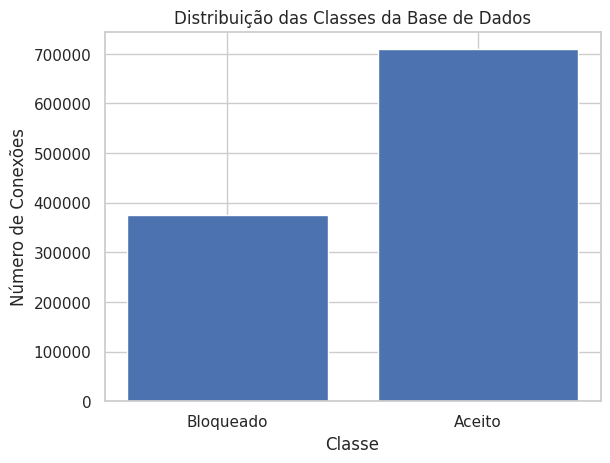

In [ ]:
import matplotlib.pyplot as plt

distribuicao = df['aceito'].value_counts().sort_index()

labels = ['Bloqueado', 'Aceito']

plt.figure()

plt.bar(labels, distribuicao.values)

plt.title("Distribuição das Classes da Base de Dados")
plt.xlabel("Classe")
plt.ylabel("Número de Conexões")

plt.savefig("distribuicao_classes.png", dpi=300)

plt.show()

## Célula 4 – Separação dos Dados em Conjunto de Treinamento e Teste

Nesta etapa, o conjunto de dados é dividido em dois subconjuntos distintos: **treinamento** e **teste**. Essa separação é fundamental para avaliar corretamente o desempenho dos modelos de Inteligência Artificial, garantindo que eles sejam testados com dados que não foram utilizados durante o processo de aprendizado.

O conjunto de **treinamento** é utilizado para ajustar os parâmetros dos modelos de Regressão Logística e Árvore de Decisão, enquanto o conjunto de **teste** é reservado exclusivamente para a avaliação do desempenho, permitindo medir a capacidade de generalização dos modelos.

Para realizar essa divisão, foi utilizado o método `train_test_split`, da biblioteca *scikit-learn*. A base de dados foi separada da seguinte forma:
- 70% dos dados para treinamento
- 30% dos dados para teste

Além disso, foi utilizado o parâmetro `random_state` para garantir a reprodutibilidade dos resultados, assegurando que a mesma divisão seja obtida em diferentes execuções do código.

Ao final desta etapa, são exibidas as dimensões dos conjuntos gerados, confirmando que a separação foi realizada corretamente.

In [ ]:
# -----------------------------
# Separação entre features (X) e target (y)
# -----------------------------

# Adiciona uma verificação para garantir que df não é None
if df is None:
    print("Erro: DataFrame não carregado. Não é possível dividir os dados. Verifique a CÉLULA 2.")
else:
    X = df.drop(columns=["aceito"])
    y = df["aceito"]

    # -----------------------------
    # Divisão em treino e teste
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    # -----------------------------
    # Verificação das dimensões
    # -----------------------------
    print("Dimensões dos conjuntos:")
    print(f"X_train: {X_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"y_test: {y_test.shape}")

Dimensões dos conjuntos:
X_train: (758950, 10)
X_test: (325265, 10)
y_train: (758950,)
y_test: (325265,)


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Criando o objeto de undersampling
rus = RandomUnderSampler(random_state=42)

# Aplicando APENAS nos dados de treino
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

# Verificação dos resultados
print("Verificação do Balanceamento (Conjunto de Treino):")
print(y_train_res.value_counts())

print("\nVerificação do Teste (Permanece Original/Desbalanceado):")
print(y_test.value_counts())

Verificação do Balanceamento (Conjunto de Treino):
aceito
0    262488
1    262488
Name: count, dtype: int64

Verificação do Teste (Permanece Original/Desbalanceado):
aceito
1    212770
0    112495
Name: count, dtype: int64


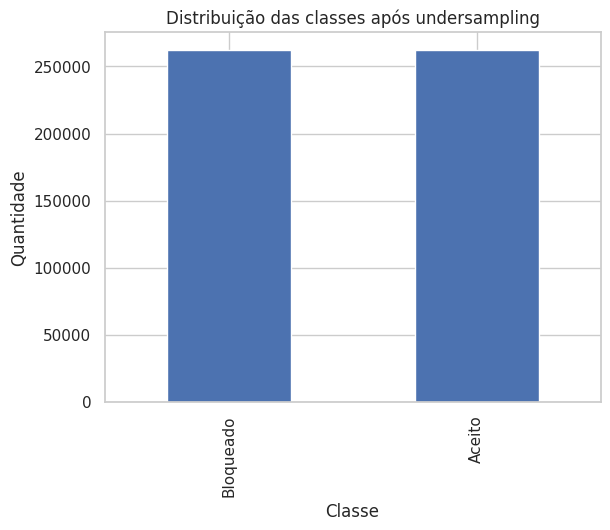

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

y_train_res.value_counts().plot(kind='bar')

plt.title("Distribuição das classes após undersampling")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.xticks([0,1], ["Bloqueado", "Aceito"])

plt.show()

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal = scaler.fit_transform(X_train_bal)
X_test = scaler.transform(X_test)

### **CÉLULA 5: TREINAMENTO DOS MODELOS DE MACHINE LEARNING**

Nesta etapa, realizamos o treinamento dos dois modelos de Machine Learning definidos para o projeto: **Regressão Logística** e **Árvore de Decisão**. O objetivo do treinamento é permitir que os algoritmos aprendam padrões existentes nos dados de treinamento e sejam capazes de generalizar essas informações para novos dados.

Inicialmente, instanciamos cada modelo com seus parâmetros padrão, garantindo simplicidade e clareza na análise comparativa. Em seguida, utilizamos o método `fit()` para ajustar os modelos aos dados de treinamento (`X_train` e `y_train`), processo no qual ocorre o aprendizado supervisionado.

A **Regressão Logística** é um modelo estatístico amplamente utilizado para problemas de classificação binária, estimando a probabilidade de uma instância pertencer a uma determinada classe. Já a **Árvore de Decisão** é um modelo baseado em regras, que realiza divisões sucessivas nos dados a partir de critérios matemáticos, facilitando a interpretação das decisões tomadas.

Ao final do treinamento, os modelos ficam prontos para serem avaliados utilizando o conjunto de teste, que contém dados não vistos durante o processo de aprendizado.

In [ ]:
# =============================================================================
# CÉLULA 5: TREINAMENTO DOS MODELOS
# =============================================================================

import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# Verificar se os dados de treino existem
try:
    # =====================================================
    # MODELO 1: REGRESSÃO LOGÍSTICA (COM BALANCEAMENTO)
    # =====================================================
    print("Treinando Regressão Logística...")

    inicio_logistico = time.time()

    modelo_logistico = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   
        random_state=42,
        n_jobs=-1                  # Usa todos os núcleos (se disponível)
    )

    modelo_logistico.fit(X_train_bal, y_train_bal)

    fim_logistico = time.time()
    tempo_logistico = fim_logistico - inicio_logistico

    print("Regressão Logística treinada com sucesso!")
    print(f"Tempo de treinamento: {tempo_logistico:.4f} segundos\n")

    # =====================================================
    # MODELO 2: ÁRVORE DE DECISÃO
    # =====================================================
    print("Treinando Árvore de Decisão...")

    inicio_arvore = time.time()

    modelo_arvore = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'   
    )

    modelo_arvore.fit(X_train_bal, y_train_bal) 

    fim_arvore = time.time()
    tempo_arvore = fim_arvore - inicio_arvore

    print("Árvore de Decisão treinada com sucesso!")
    print(f"Tempo de treinamento: {tempo_arvore:.4f} segundos\n")

    # =====================================================
    # COMPARAÇÃO DE TEMPO
    # =====================================================
    print("======= COMPARAÇÃO DE TEMPO DE TREINAMENTO ======")
    print(f"Regressão Logística: {tempo_logistico:.4f} segundos")
    print(f"Árvore de Decisão:   {tempo_arvore:.4f} segundos")

    if tempo_logistico > tempo_arvore:
        print("➡ A Regressão Logística demorou mais para treinar.")
    else:
        print("➡ A Árvore de Decisão demorou mais para treinar.")

except NameError:
    print("Erro: X_train e y_train não encontrados.")
    print("Verifique se as CÉLULAS de carregamento e separação dos dados foram executadas.")


Treinando Regressão Logística...
Regressão Logística treinada com sucesso!
Tempo de treinamento: 4.0980 segundos

Treinando Árvore de Decisão...
Árvore de Decisão treinada com sucesso!
Tempo de treinamento: 4.0685 segundos

======= COMPARAÇÃO DE TEMPO DE TREINAMENTO ======
Regressão Logística: 4.0980 segundos
Árvore de Decisão:   4.0685 segundos
➡ A Regressão Logística demorou mais para treinar.


### **CÉLULA 6: AVALIAÇÃO DOS MODELOS**

Nesta etapa, avaliamos o desempenho dos modelos treinados utilizando o conjunto de teste, que contém dados não vistos durante o treinamento. O objetivo dessa avaliação é verificar a capacidade de generalização dos modelos e comparar seus resultados de forma quantitativa.

Para essa análise, utilizamos métricas amplamente adotadas em problemas de classificação binária: **acurácia**, **precisão**, **recall** e **F1-score**. Além disso, é apresentada a **matriz de confusão**, que permite uma visualização clara dos acertos e erros cometidos pelos modelos.

As métricas são calculadas a partir das previsões realizadas pelos modelos sobre o conjunto de teste (`X_test`) e comparadas com os valores reais (`y_test`). Essa etapa é fundamental para determinar qual modelo apresenta melhor desempenho no problema proposto.

 AVALIAÇÃO DO MODELO: Regressão Logística
Acurácia : 0.7427
Precisão : 0.8960
Recall   : 0.6863
F1-score : 0.7773

 Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.59      0.85      0.70    112495
           1       0.90      0.69      0.78    212770

    accuracy                           0.74    325265
   macro avg       0.74      0.77      0.74    325265
weighted avg       0.79      0.74      0.75    325265



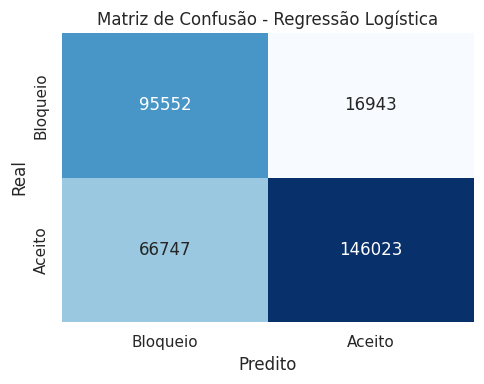

 AVALIAÇÃO DO MODELO: Árvore de Decisão
Acurácia : 0.7576
Precisão : 0.8562
Recall   : 0.7565
F1-score : 0.8033

 Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.62      0.76      0.68    112495
           1       0.86      0.76      0.80    212770

    accuracy                           0.76    325265
   macro avg       0.74      0.76      0.74    325265
weighted avg       0.78      0.76      0.76    325265



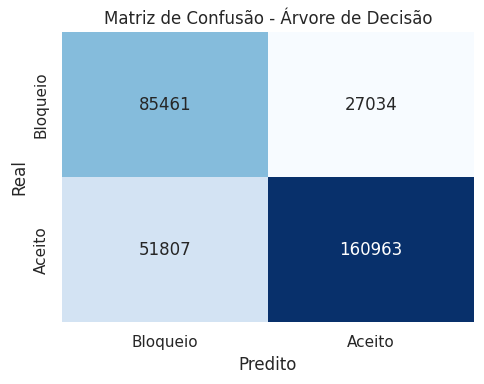

In [ ]:
# =============================================================================
# CÉLULA 6: AVALIAÇÃO DOS MODELOS
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# FUNÇÃO PADRÃO DE AVALIAÇÃO
# ============================================================
def avaliar_modelo(nome_modelo, y_test, y_pred):
    print("=" * 60)
    print(f" AVALIAÇÃO DO MODELO: {nome_modelo}")
    print("=" * 60)

    # Métricas principais
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Acurácia : {acc:.4f}")
    print(f"Precisão : {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # Relatório de classificação
    print("\n Relatório de Classificação:")
    print(classification_report(y_test, y_pred))

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Bloqueio', 'Aceito'],
        yticklabels=['Bloqueio', 'Aceito']
    )
    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()


# ============================================================
# MODELO 1: REGRESSÃO LOGÍSTICA
# ============================================================
y_pred_logistico = modelo_logistico.predict(X_test)

avaliar_modelo(
    nome_modelo="Regressão Logística",
    y_test=y_test,
    y_pred=y_pred_logistico
)


# ============================================================
# MODELO 2: ÁRVORE DE DECISÃO
# ============================================================
y_pred_arvore = modelo_arvore.predict(X_test)

avaliar_modelo(
    nome_modelo="Árvore de Decisão",
    y_test=y_test,
    y_pred=y_pred_arvore
)

## Célula Final – Comparação dos Modelos de Classificação

Nesta etapa final do projeto, realizamos a **comparação quantitativa e visual** dos modelos de *Machine Learning* treinados anteriormente: **Regressão Logística** e **Árvore de Decisão**.  
O objetivo é avaliar o desempenho de cada modelo de forma padronizada, permitindo identificar qual deles apresenta melhores resultados para o problema de classificação proposto.

### Métricas Utilizadas

A avaliação dos modelos foi realizada com base nas seguintes métricas:

- **Acurácia**: proporção total de previsões corretas em relação ao número total de amostras.
- **Precisão**: indica a confiabilidade das previsões positivas feitas pelo modelo.
- **Recall (Sensibilidade)**: mede a capacidade do modelo de identificar corretamente os casos positivos.
- **F1-score**: média harmônica entre precisão e recall, sendo especialmente útil em conjuntos de dados desbalanceados.

Essas métricas foram calculadas a partir dos dados de teste, garantindo uma avaliação justa do desempenho dos modelos em dados não vistos durante o treinamento.

### Comparação Lado a Lado

Os resultados das métricas foram organizados em um *DataFrame* comparativo, permitindo a análise direta e objetiva do desempenho dos dois modelos. Essa tabela facilita a identificação de diferenças entre os algoritmos e auxilia na tomada de decisão sobre qual modelo é mais adequado para o problema estudado.

### Visualização Gráfica

Além da tabela comparativa, foi gerado um **gráfico de barras** para representar visualmente o desempenho dos modelos em cada métrica. Essa visualização facilita a interpretação dos resultados, destacando pontos fortes e fracos de cada abordagem de forma intuitiva.

### Considerações Finais

A comparação final permite concluir qual modelo apresentou melhor desempenho geral, levando em conta não apenas a acurácia, mas também métricas mais robustas como *recall* e *F1-score*. Essa análise é fundamental para garantir que o modelo escolhido seja confiável e adequado ao contexto do problema, especialmente em cenários onde erros de classificação podem ter impactos significativos.

Essa etapa consolida todo o processo de pré-processamento, treinamento e avaliação, fornecendo uma visão clara e fundamentada dos resultados obtidos.


--- Comparação Lado a Lado ---



,Métrica,Regressão Logística,Árvore de Decisão
0,Acurácia,0.742702,0.757610
1,Precisão,0.896034,0.856200
2,Recall,0.686295,0.756512
3,F1-Score,0.777264,0.803275


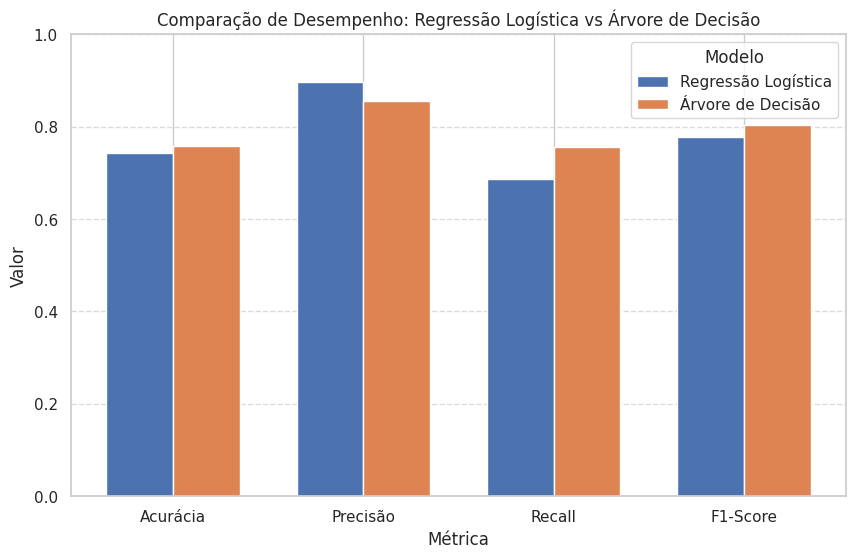

In [ ]:
# =============================================================================
# CÉLULA FINAL: COMPARAÇÃO LADO A LADO DOS MODELOS
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# Cálculo das métricas
# -----------------------------
metricas = {
    "Métrica": ["Acurácia", "Precisão", "Recall", "F1-Score"],
    "Regressão Logística": [
        accuracy_score(y_test, y_pred_logistico),
        precision_score(y_test, y_pred_logistico, zero_division=0),
        recall_score(y_test, y_pred_logistico, zero_division=0),
        f1_score(y_test, y_pred_logistico, zero_division=0)
    ],
    "Árvore de Decisão": [
        accuracy_score(y_test, y_pred_arvore),
        precision_score(y_test, y_pred_arvore, zero_division=0),
        recall_score(y_test, y_pred_arvore, zero_division=0),
        f1_score(y_test, y_pred_arvore, zero_division=0)
    ]
}

# Criar DataFrame
df_comparacao = pd.DataFrame(metricas)

print("\n--- Comparação Lado a Lado ---\n")
display(df_comparacao)

# -----------------------------
# Gráfico de barras lado a lado
# -----------------------------
labels = df_comparacao["Métrica"]
log_values = df_comparacao["Regressão Logística"]
arvore_values = df_comparacao["Árvore de Decisão"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))

# Cores personalizadas
plt.bar(x - width/2, log_values, width, label="Regressão Logística", color="#4C72B0")
plt.bar(x + width/2, arvore_values, width, label="Árvore de Decisão", color="#DD8452")

plt.title("Comparação de Desempenho: Regressão Logística vs Árvore de Decisão")
plt.ylabel("Valor")
plt.xlabel("Métrica")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend(title="Modelo")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()